<a href="https://colab.research.google.com/github/manasabt1997-max/practice-basics/blob/main/Manasa_B_T_Data_science_assignment_Q4_%26_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q.4

WORKFLOW FOR PCA

The workflow for Principal Component Analysis (PCA) reduces data size while keeping the most important patterns and variance

**Steps**

* Standardize the data: Scale features so each variable has a mean of 0 and a variance of 1, preventing large-scale features from dominating.

* Compute the covariance matrix: Calculate how each variable relates to every other variable in the dataset.

* Perform eigen decomposition: Extract the eigenvectors and eigenvalues from the covariance matrix to find the principal components.

* Rank and select components: Sort eigenvalues from highest to lowest and pick the top k eigenvectors that capture the most variance.

* Transform the data: Project the original dataset onto the new lower-dimensional subspace created by the selected principal components


In [ ]:
#imprt libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.decomposition import PCA

In [ ]:
data = datasets.load_breast_cancer()

breast_data = data.data
breast_labels = data.target

labels = np.reshape(breast_labels,(569,1))
final_data = np.concatenate([breast_data,labels],axis=1)

breast_dataset = pd.DataFrame(final_data)
features = data.feature_names

features_labels = np.append(features,'label')

breast_dataset.columns = features_labels
breast_dataset.sample(4)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
220,13.650,13.16,87.88,568.9,0.09646,0.08711,0.03888,0.02563,0.1360,0.06344,...,16.35,99.71,706.2,0.1311,0.24740,0.17590,0.08056,0.2380,0.08718,1.0
42,19.070,24.81,128.30,1104.0,0.09081,0.21900,0.21070,0.09961,0.2310,0.06343,...,33.17,177.40,1651.0,0.1247,0.74440,0.72420,0.24930,0.4670,0.10380,0.0
234,9.567,15.91,60.21,279.6,0.08464,0.04087,0.01652,0.01667,0.1551,0.06403,...,19.16,65.74,335.9,0.1504,0.09515,0.07161,0.07222,0.2757,0.08178,1.0
488,11.680,16.17,75.49,420.5,0.11280,0.09263,0.04279,0.03132,0.1853,0.06401,...,21.59,86.57,549.8,0.1526,0.14770,0.14900,0.09815,0.2804,0.08024,1.0


In [ ]:
breast_dataset['label'].replace(0, 'Benign',inplace=True)
breast_dataset['label'].replace(1, 'Malignant',inplace=True)
breast_dataset.sample(4)

/tmp/ipykernel_3076/2346330469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  breast_dataset['label'].replace(0, 'Benign',inplace=True)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
443,10.57,18.32,66.82,340.9,0.08142,0.04462,0.01993,0.01111,0.2372,0.05768,...,23.31,69.35,366.3,0.09794,0.06542,0.03986,0.02222,0.2699,0.06736,Malignant
389,19.55,23.21,128.90,1174.0,0.10100,0.13180,0.18560,0.10210,0.1989,0.05884,...,30.44,142.00,1313.0,0.12510,0.24140,0.38290,0.18250,0.2576,0.07602,Benign
528,13.94,13.17,90.31,594.2,0.12480,0.09755,0.10100,0.06615,0.1976,0.06457,...,15.38,94.52,653.3,0.13940,0.13640,0.15590,0.10150,0.2160,0.07253,Malignant
506,12.22,20.04,79.47,453.1,0.10960,0.11520,0.08175,0.02166,0.2124,0.06894,...,24.17,85.13,515.3,0.14020,0.23150,0.35350,0.08088,0.2709,0.08839,Malignant


In [ ]:
#PCA
#normalization of data
from sklearn.preprocessing import StandardScaler
x = breast_dataset.loc[:, features].values
x = StandardScaler().fit_transform(x)

np.mean(x),np.std(x)

feat_cols = ['feature'+str(i) for i in range(x.shape[1])]
normalised_breast = pd.DataFrame(x,columns=feat_cols)
normalised_breast.sample(4)

,feature0,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,...,feature20,feature21,feature22,feature23,feature24,feature25,feature26,feature27,feature28,feature29
315,-0.465014,-0.567723,-0.526371,-0.492852,-0.800631,-1.250816,-1.058714,-1.096145,-2.178221,-0.860147,...,-0.606584,-0.971725,-0.678558,-0.591332,-0.963013,-1.302401,-1.212855,-1.321154,-1.591501,-1.230554
516,1.187949,0.300273,1.187553,1.129424,0.742947,0.387729,0.855002,1.175970,0.176638,-0.480229,...,1.157759,0.085131,1.040681,1.076575,0.737820,-0.004231,0.497558,0.554153,0.280271,-0.294580
119,1.085703,0.167631,0.915698,0.930337,-0.878202,-0.703498,-0.199239,0.181612,1.158741,-1.778754,...,0.892693,0.350566,0.653465,0.668740,-1.103288,-0.852841,-0.226868,0.059289,3.205219,-1.265465
268,-0.357089,-0.716655,-0.394974,-0.405822,-0.150179,-0.798824,-0.625229,-0.845247,0.724279,-0.724057,...,-0.490618,-0.331749,-0.535883,-0.497635,-0.296707,-0.467340,-0.350164,-0.864965,1.137695,-0.738461


In [ ]:
#dimentionality reduction
pca_breast = PCA(n_components=2)
principalComponents_breast = pca_breast.fit_transform(x)

principal_breast_Df = pd.DataFrame(data = principalComponents_breast
             , columns = ['principal component 1', 'principal component 2'])
principal_breast_Df.sample(4)

,principal component 1,principal component 2
313,-4.038017,-0.240698
122,12.894612,2.316622
349,-1.928795,1.461470
394,-2.010379,0.429690


<Figure size 640x480 with 0 Axes>

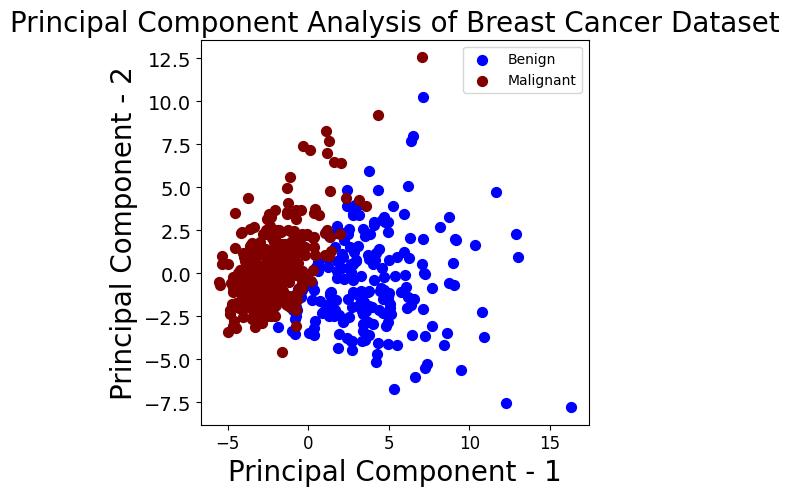

In [ ]:
#Visualization
plt.figure()
plt.figure(figsize=(5,5))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1',fontsize=20)
plt.ylabel('Principal Component - 2',fontsize=20)
plt.title("Principal Component Analysis of Breast Cancer Dataset",fontsize=20)
targets = ['Benign', 'Malignant']
colors = ['blue', 'maroon']
for target, color in zip(targets,colors):
    indicesToKeep = breast_dataset['label'] == target
    plt.scatter(principal_breast_Df.loc[indicesToKeep, 'principal component 1']
               , principal_breast_Df.loc[indicesToKeep, 'principal component 2'], c = color, s = 50)

    plt.legend(targets,prop={'size': 10})

Q5. data visualization

In [ ]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#import dataset
df = pd.read_csv('/content/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


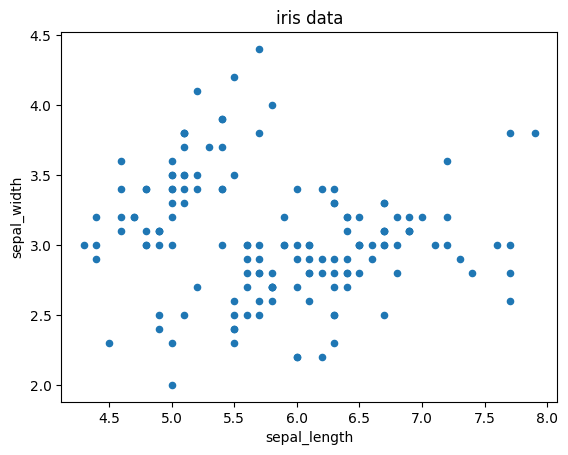

In [ ]:
#create plots
#scatter plot
plt.figure
df.plot(title= 'iris data', kind='scatter', x='sepal_length', y='sepal_width')
plt.show()


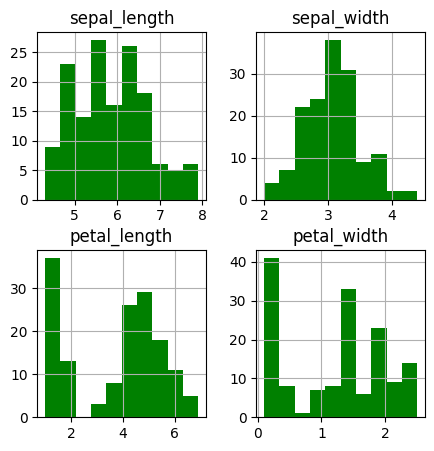

In [ ]:
#histogram
df.hist(figsize=(5,5), color= 'green')
plt.show()

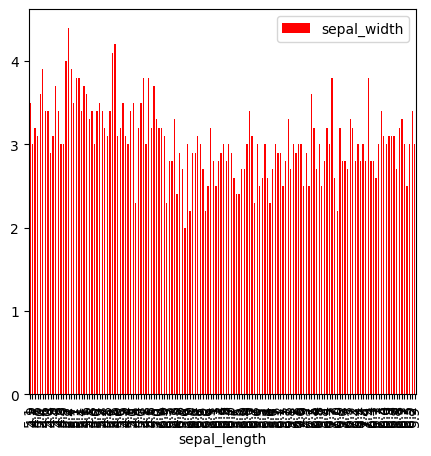

In [ ]:
#bar plot
df.plot(kind='bar', x='sepal_length', y='sepal_width', color= 'red', figsize=(5,5))
plt.show()

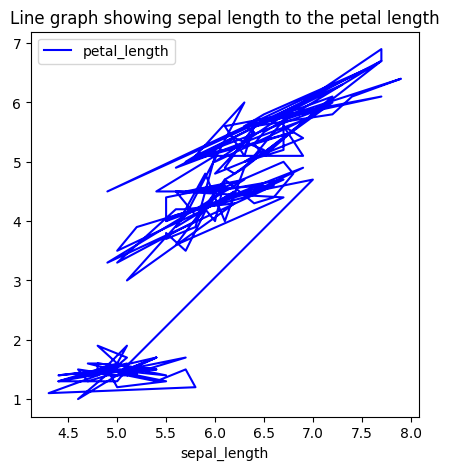

In [ ]:
df.plot(title= 'Line graph showing sepal length to the petal length', kind= 'line', x='sepal_length', y='petal_length', color= 'blue', figsize=(5,5))
plt.show()